**© 2026 Mindverse Computing LLC.**  
Licensed under CC BY-NC 4.0.  
See LICENSE file for patent and commercial restrictions.

# Variational Phasor Circuit (VPC)
In this notebook, we demonstrate how to use `PhasorFlow` for Machine Learning by optimizing a continuous-parameter Phasor Circuit.

This is analogous to a Variational Quantum Circuit (VQC) in Quantum Machine Learning, but operating entirely on natively classical, deterministic unit circle vectors.


In [ ]:
# (c) 2026 Mindverse Computing LLC.
# Licensed under CC BY-NC 4.0.
# See LICENSE file for patent and commercial restrictions.

import sys
import os
sys.path.append(os.path.abspath('..'))

import phasorflow as pf
from phasorflow.engine.analytic import AnalyticEngine
import torch
import torch.nn as nn
import torch.optim as optim
import math

torch.manual_seed(42)

## 1. Synthetic Data Generation
We will create a synthetic two-class dataset with $N=16$ features.
The dataset will contain 1000 samples, and the goal of our VPC is to correctly classify them.


In [2]:
num_samples = 1000
num_features = 16

# Generate random features in range [0, 2pi]
X = torch.empty(num_samples, num_features).uniform_(0, 2*math.pi)

# Create a true non-linear boundary based on the complex phases
# E.g. If the sum of cosine projections is > 0, Class 1, else Class 0
true_signals = torch.sum(torch.cos(X), dim=1)
y = (true_signals > 0).float()

print(f"Dataset generated: {X.shape} features, {y.shape} labels.")

train_size = int(0.8 * num_samples)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

Dataset generated: torch.Size([1000, 16]) features, torch.Size([1000]) labels.


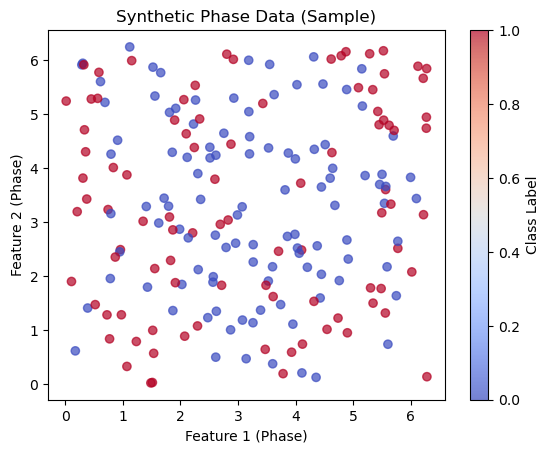

In [3]:
# Plot the sample of synthetic data
import matplotlib.pyplot as plt
class_0_mean = torch.mean(X[y == 0], dim=0).numpy()
class_1_mean = torch.mean(X[y == 1], dim=0).numpy()
plt.scatter(X[:200, 0].numpy(), X[:200, 1].numpy(), c=y[:200].numpy(), cmap='coolwarm', alpha=0.7)
plt.xlabel('Feature 1 (Phase)')
plt.ylabel('Feature 2 (Phase)')
plt.title('Synthetic Phase Data (Sample)')
plt.colorbar(label='Class Label')
plt.show()




## 2. Definining the Variational Phasor Circuit (VPC) Structure
Our VPC will consist of:
1. **Data Encoding**: Feature values are encoded as absolute phase shifts `S(phi)`.
2. **Variational Layers**: Trainable weights are passed into phase shifts, interleaved with `Mix` and `DFT` gates to create interference and thread correlations.


In [4]:
def create_vpc(x, weights):
    """
    Builds the PhasorCircuit based on data x and parameters `weights`.
    Weights should be an array of length 2*num_features (64 for Layer 1, 64 for Layer 2).
    """
    pc = pf.PhasorCircuit(num_features, name="VPC_Classifier")
    
    # --- DATA ENCODING ---
    for i in range(num_features):
        pc.shift(i, x[i])
        
    # --- VARIATIONAL LAYER 1 ---
    for i in range(num_features):
        pc.shift(i, weights[i])
        
    # Introduce local interference
    for i in range(0, num_features-1, 2):
        pc.mix(i, i+1)
        
    # --- VARIATIONAL LAYER 2 ---
    for i in range(num_features):
        pc.shift(i, weights[i + num_features])
        
    # Introduce global interference / "Entanglement"
    pc.dft()
    
    return pc

# Let's visualize an un-optimized circuit structure:
dummy_w = torch.zeros(2 * num_features)
test_pc = create_vpc(X[0], dummy_w)
print("VPC Architecture Preview:")
pf.draw(test_pc, mode='text')

VPC Architecture Preview:
T0: ──[S(5.54)]───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────[S(0.00)]─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────────────────────────────────────────────────[S(0.00)]─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────┤
                                                                                                                                                                                                                                                                                                                                                                      [MIX]            

## 3. Loss Function
To train our weights, we must measure the circuit. Since Phase runs from $[-\pi, \pi]$, we will measure the angle of Thread 0, map it to a probability $[0, 1]$ using a sine envelope, and calculate Mean Squared Error.


In [5]:
engine = AnalyticEngine()

def vpc_predict(x, weights):
    pc = create_vpc(x, weights)
    res = engine.run(pc)
    
    # Read the phase of Thread 0
    phase_0 = res['phases'][0]
    
    # Map phase [-pi, pi] to probability [0, 1] using (sin(theta) + 1) / 2
    probability = (torch.sin(phase_0) + 1.0) / 2.0
    return probability
    
def calculate_loss(weights, X_data, y_data):
    predictions = torch.stack([vpc_predict(x, weights) for x in X_data])
    
    # Mean Squared Error
    mse = torch.mean((predictions - y_data)**2)
    binary_predictions = (predictions > 0.5).float()
    accuracy = torch.mean((binary_predictions == y_data).float())
    return mse, accuracy

# Initial loss with random weights
initial_weights = torch.empty(2 * num_features).uniform_(-math.pi, math.pi)
initial_weights.requires_grad_(True)
initial_loss, initial_acc = calculate_loss(initial_weights, X_train, y_train)
print(f"Initial Random MSE Loss: {initial_loss.item():.4f}, Accuracy: {initial_acc.item()*100:.2f}%")

Initial Random MSE Loss: 0.4706, Accuracy: 37.13%


## 4. Optimization (Training)
We use `scipy.optimize.minimize` (COBYLA) to train our 24 physical parameters to minimize the MSE.


In [6]:
print("Starting Adam Optimization Native to Unit Circle...")

optimizer = optim.Adam([initial_weights], lr=0.1)

train_losses, train_accs, val_losses, val_accs = [], [], [], []
epochs = 40
for epoch in range(epochs):
    optimizer.zero_grad()
    loss, acc = calculate_loss(initial_weights, X_train, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    train_accs.append(acc.item() * 100)
    with torch.no_grad():
        val_loss, val_acc = calculate_loss(initial_weights, X_test, y_test)
        val_losses.append(val_loss.item())
        val_accs.append(val_acc.item() * 100)
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.4f} | Val Acc: {val_acc.item()*100:.2f}%")

optimal_weights = initial_weights.detach()
final_loss = loss.item()

print(f"Optimization Complete!")
print(f"Final Trained MSE Loss: {final_loss:.4f}")

Starting Adam Optimization Native to Unit Circle...
Epoch 10/40 | Train Loss: 0.1955 | Val Acc: 78.00%
Epoch 20/40 | Train Loss: 0.0943 | Val Acc: 84.00%
Epoch 30/40 | Train Loss: 0.0679 | Val Acc: 92.50%
Epoch 40/40 | Train Loss: 0.0627 | Val Acc: 94.50%
Optimization Complete!
Final Trained MSE Loss: 0.0627


## 5. Evaluation
Let's see our VPC's classification accuracy using the optimal parameters.


Final Test Classification Accuracy: 94.50%


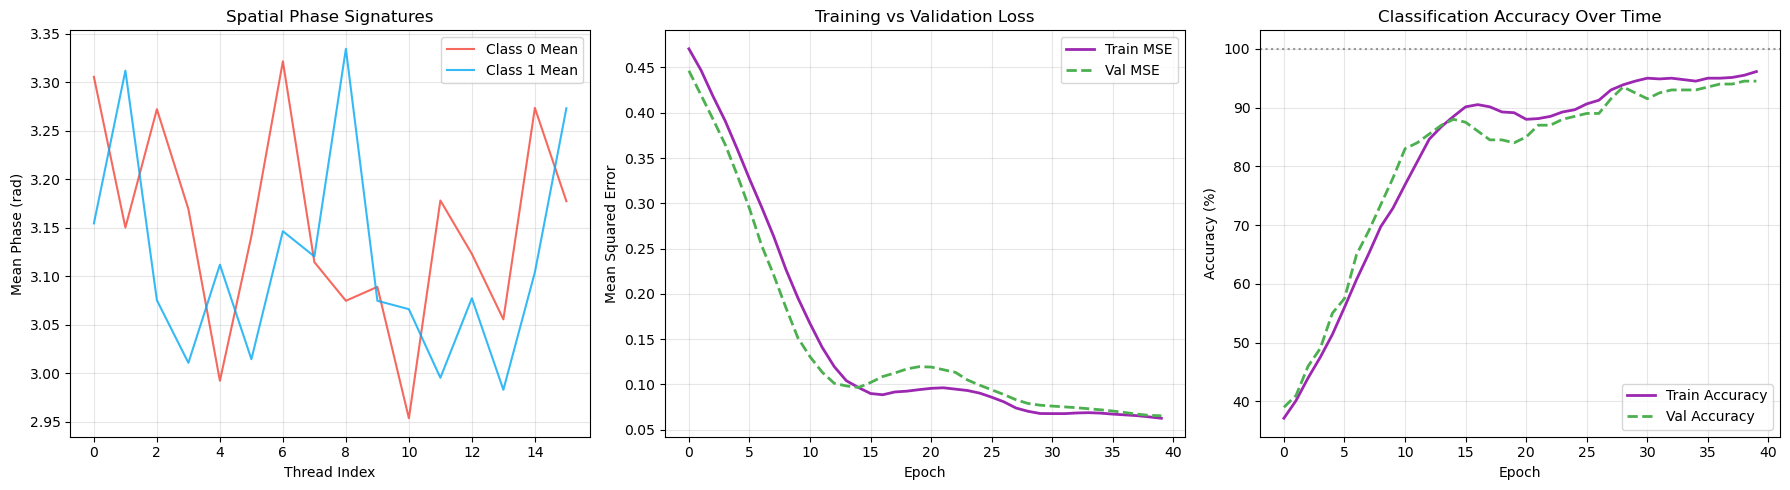

In [7]:
test_loss, test_acc = calculate_loss(optimal_weights, X_test, y_test)
print(f"Final Test Classification Accuracy: {test_acc.item()*100:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(class_0_mean, label='Class 0 Mean', color='#F44336', alpha=0.8)
axes[0].plot(class_1_mean, label='Class 1 Mean', color='#03A9F4', alpha=0.8)
axes[0].set_title('Spatial Phase Signatures')
axes[0].set_xlabel('Thread Index')
axes[0].set_ylabel('Mean Phase (rad)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_losses, label='Train MSE', color='#9C27B0', linewidth=2)
axes[1].plot(val_losses, label='Val MSE', color='#4CAF50', linewidth=2, linestyle='--')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean Squared Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(train_accs, label='Train Accuracy', color='#9C27B0', linewidth=2)
axes[2].plot(val_accs, label='Val Accuracy', color='#4CAF50', linewidth=2, linestyle='--')
axes[2].set_title('Classification Accuracy Over Time')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].axhline(y=100.0, color='gray', linestyle=':', alpha=0.8)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_vpc_single.pdf', bbox_inches='tight')
plt.show()

## 6. Manuscript-Grade Figure Exports
This section creates publication-quality multi-panel visualizations and saves both raster and vector versions for the manuscript.

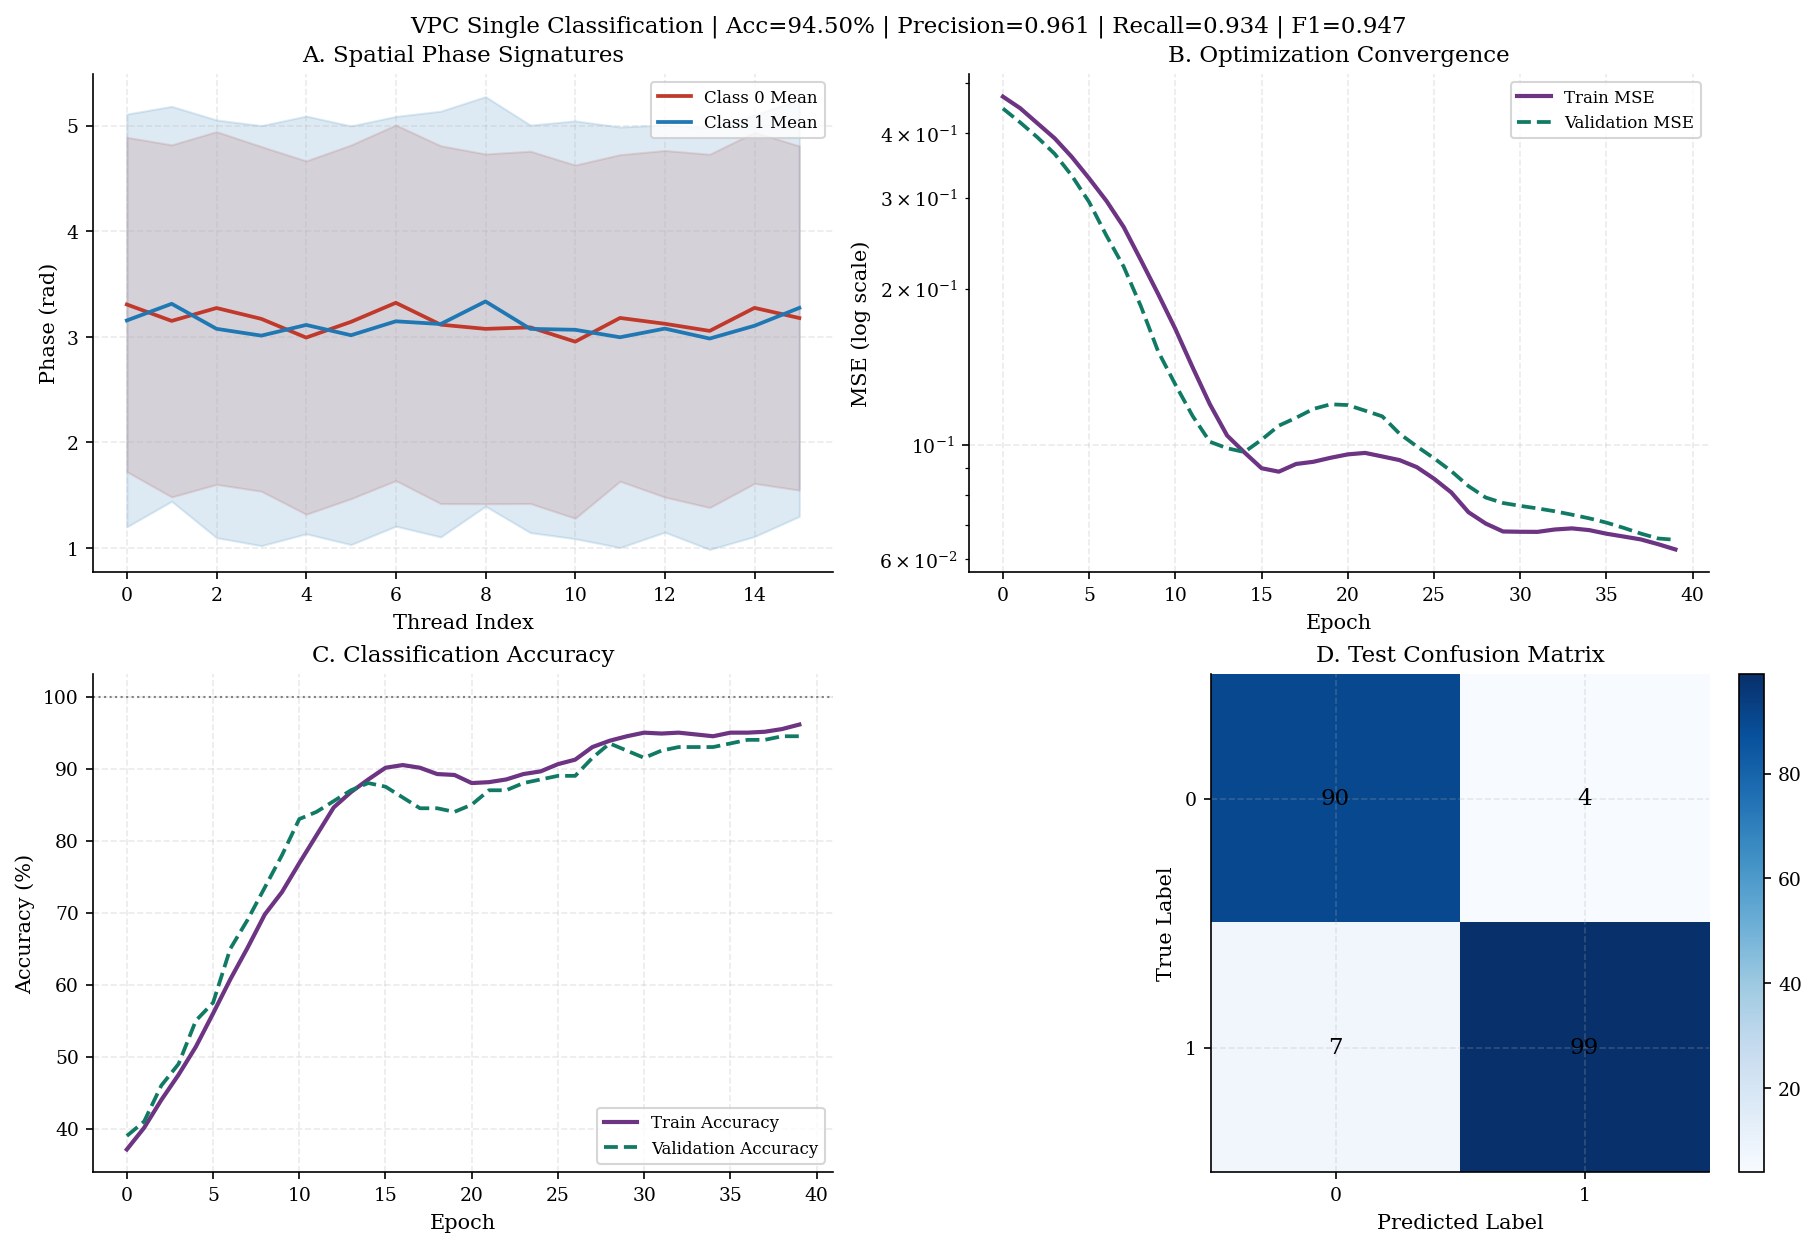

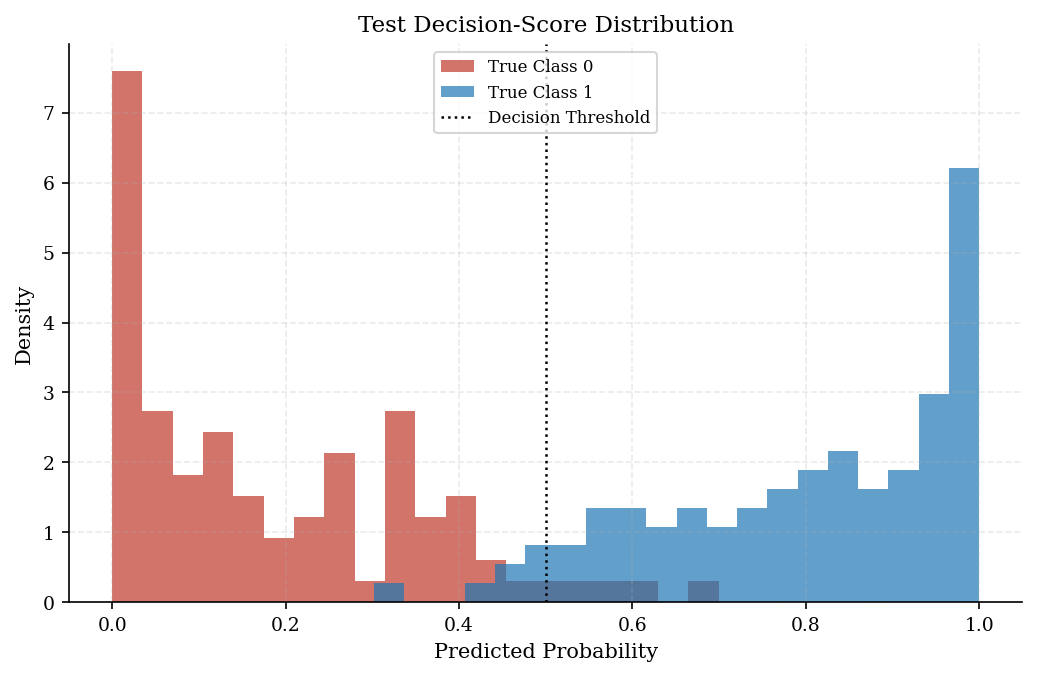

Saved multi-panel figure to: /Users/vasu/Documents/COMPUTE/C-Synchronome/C-PhasorFlow/manuscript/PhasorFlow/figures/vpc_single_multi_panel.png
Saved vector figure to: /Users/vasu/Documents/COMPUTE/C-Synchronome/C-PhasorFlow/manuscript/PhasorFlow/figures/vpc_single_multi_panel.pdf
Saved score-distribution figure to: /Users/vasu/Documents/COMPUTE/C-Synchronome/C-PhasorFlow/manuscript/PhasorFlow/figures/vpc_single_probability_distribution.png
Saved vector score-distribution figure to: /Users/vasu/Documents/COMPUTE/C-Synchronome/C-PhasorFlow/manuscript/PhasorFlow/figures/vpc_single_probability_distribution.pdf


In [8]:
from pathlib import Path
import numpy as np

# Export to manuscript figure directory.
repo_root = Path.cwd().resolve().parents[1]
figure_dir = repo_root / "manuscript" / "PhasorFlow" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Publication defaults.
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# Collect test probabilities and hard predictions.
with torch.no_grad():
    test_probs = torch.stack([vpc_predict(x, optimal_weights) for x in X_test]).detach().cpu().numpy()
y_true = y_test.detach().cpu().numpy()
y_pred = (test_probs > 0.5).astype(int)

# Confusion matrix and metrics.
tn = int(np.sum((y_true == 0) & (y_pred == 0)))
fp = int(np.sum((y_true == 0) & (y_pred == 1)))
fn = int(np.sum((y_true == 1) & (y_pred == 0)))
tp = int(np.sum((y_true == 1) & (y_pred == 1)))
cm = np.array([[tn, fp], [fn, tp]])

test_accuracy = (tp + tn) / max(len(y_true), 1)
precision = tp / max((tp + fp), 1)
recall = tp / max((tp + fn), 1)
f1 = 2 * precision * recall / max((precision + recall), 1e-12)

# Class-wise phase profile variability.
class_0_std = torch.std(X[y == 0], dim=0).numpy()
class_1_std = torch.std(X[y == 1], dim=0).numpy()
thread_idx = np.arange(num_features)

# 2x2 manuscript figure.
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Panel A: mean phase signatures with uncertainty bands.
axes[0, 0].plot(thread_idx, class_0_mean, color="#c0392b", linewidth=1.8, label="Class 0 Mean")
axes[0, 0].fill_between(thread_idx, class_0_mean - class_0_std, class_0_mean + class_0_std, color="#c0392b", alpha=0.15)
axes[0, 0].plot(thread_idx, class_1_mean, color="#1f77b4", linewidth=1.8, label="Class 1 Mean")
axes[0, 0].fill_between(thread_idx, class_1_mean - class_1_std, class_1_mean + class_1_std, color="#1f77b4", alpha=0.15)
axes[0, 0].set_title("A. Spatial Phase Signatures")
axes[0, 0].set_xlabel("Thread Index")
axes[0, 0].set_ylabel("Phase (rad)")
axes[0, 0].legend(loc="upper right")

# Panel B: training and validation loss.
axes[0, 1].plot(train_losses, color="#6c3483", linewidth=2.0, label="Train MSE")
axes[0, 1].plot(val_losses, color="#117a65", linewidth=1.8, linestyle="--", label="Validation MSE")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("B. Optimization Convergence")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("MSE (log scale)")
axes[0, 1].legend(loc="upper right")

# Panel C: training and validation accuracy.
axes[1, 0].plot(train_accs, color="#6c3483", linewidth=2.0, label="Train Accuracy")
axes[1, 0].plot(val_accs, color="#117a65", linewidth=1.8, linestyle="--", label="Validation Accuracy")
axes[1, 0].axhline(y=100.0, color="gray", linestyle=":", linewidth=1.0)
axes[1, 0].set_title("C. Classification Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy (%)")
axes[1, 0].legend(loc="lower right")

# Panel D: confusion matrix.
im = axes[1, 1].imshow(cm, cmap="Blues")
axes[1, 1].set_title("D. Test Confusion Matrix")
axes[1, 1].set_xlabel("Predicted Label")
axes[1, 1].set_ylabel("True Label")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(["0", "1"])
axes[1, 1].set_yticklabels(["0", "1"])
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=11)
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

fig.suptitle(
    f"VPC Single Classification | Acc={test_accuracy*100:.2f}% | Precision={precision:.3f} | Recall={recall:.3f} | F1={f1:.3f}",
    fontsize=11,
    y=1.02
)

multi_png = figure_dir / "vpc_single_multi_panel.png"
multi_pdf = figure_dir / "vpc_single_multi_panel.pdf"
fig.savefig(multi_png, bbox_inches="tight")
fig.savefig(multi_pdf, bbox_inches="tight")
plt.show()

# Supplementary decision-score distribution plot.
fig2, ax2 = plt.subplots(figsize=(6.8, 4.4), constrained_layout=True)
ax2.hist(test_probs[y_true == 0], bins=20, alpha=0.7, color="#c0392b", label="True Class 0", density=True)
ax2.hist(test_probs[y_true == 1], bins=20, alpha=0.7, color="#1f77b4", label="True Class 1", density=True)
ax2.axvline(0.5, color="black", linestyle=":", linewidth=1.2, label="Decision Threshold")
ax2.set_title("Test Decision-Score Distribution")
ax2.set_xlabel("Predicted Probability")
ax2.set_ylabel("Density")
ax2.legend(loc="upper center")
dist_png = figure_dir / "vpc_single_probability_distribution.png"
dist_pdf = figure_dir / "vpc_single_probability_distribution.pdf"
fig2.savefig(dist_png, bbox_inches="tight")
fig2.savefig(dist_pdf, bbox_inches="tight")
plt.show()

print(f"Saved multi-panel figure to: {multi_png}")
print(f"Saved vector figure to: {multi_pdf}")
print(f"Saved score-distribution figure to: {dist_png}")
print(f"Saved vector score-distribution figure to: {dist_pdf}")